## Section: Sep 17, 2025
### Kamal Dalal
<br>

### <font color="blue">Overview of NLP and its applications, basic text processing (tokenization)</font>

In this notebook, we'll cover:
-

## What is Natural Language Processing (NLP)?

Natural Language Processing (NLP) is a subfield of Artificial Intelligence (AI) and Computational Linguistics that focuses on the interaction between computers and human (natural) languages. Formally, it is defined as:

> *“Natural Language Processing (NLP) is a field of computer science, artificial intelligence, and linguistics concerned with the interactions between computers and human (natural) languages, and, in particular, how to program computers to process and analyze large amounts of natural language data.”*  
> — [Liddy, 2001; Jurafsky & Martin, 2023]

In simpler terms, NLP enables computers to **understand, interpret, and generate human language** in a way that is meaningful and useful. It brings together techniques from linguistics (syntax, semantics, pragmatics) and machine learning to transform unstructured text or speech into structured information.

## Why Language Matters

Language is special because it’s how people **share ideas, feelings, and stories**. It lets us **work together, learn from each other, and pass knowledge** from one generation to the next. Without language, there would be no books, no science, and no way to build communities. Since most of what humans create and communicate is in language, computers also need to learn how to understand it — and that’s exactly what **NLP (Natural Language Processing)** does.


## The Journey of NLP

The field of Natural Language Processing (NLP) has gone through several important stages of evolution:

1. **Rule-Based Era (1950s–1980s)**  
   - Early NLP systems relied on **hand-crafted grammar rules and dictionaries**.  
   - Famous milestone: **ELIZA (1966)**, an early chatbot that simulated conversation using pattern matching. The Eliza chatbot was created by MIT scientist Joseph Weizenbaum in 1966.
   - Limitations: fragile, couldn’t scale to complex language.

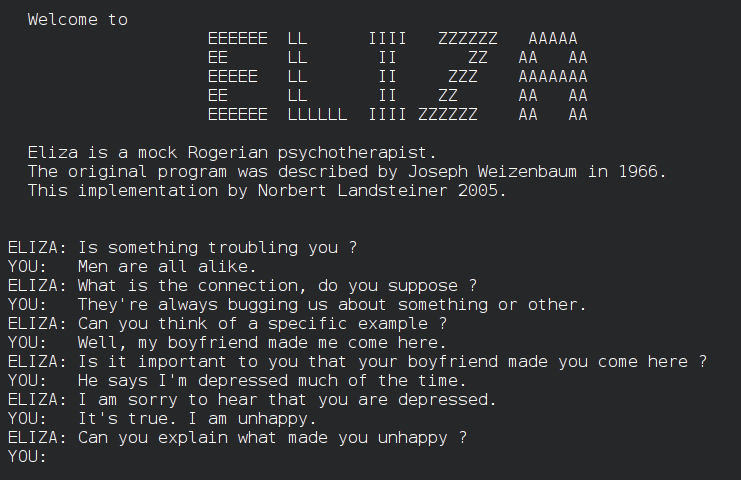

2. **Statistical Era (1990s–2000s)**  
   - With more data and faster computers, NLP shifted to **statistical methods**.  
   - Techniques: Hidden Markov Models, n-grams, probabilistic parsing.  
   - Milestones: **IBM’s statistical machine translation**, part-of-speech tagging with probabilities.  
   - Key shift: data-driven models replaced hand-written rules.

   Ref: https://mt-archive.net/UMIST-1990-Sharman.pdf




3. **Neural Networks & Deep Learning Era (2010s)**  
   - Introduction of **word embeddings** (Word2Vec, GloVe) captured semantic meaning.  
   - Recurrent Neural Networks (RNNs), LSTMs, and later CNNs were applied to NLP tasks like sentiment analysis, translation, and question answering.  
   - Systems became more robust but still struggled with long-term dependencies.

4. **Transformers & Pretrained Language Models (2017–Present)**  
   - The paper *“Attention is All You Need” (2017)* introduced the **Transformer architecture**.  
   - Pretrained models like **BERT (2018)**, **GPT series (2018–present)**, and **T5** revolutionized NLP.  
   - These models can **understand context, generate coherent text, and perform multiple tasks** with minimal fine-tuning.  
   - Current trend: **large language models (LLMs)** that power applications like ChatGPT, Bard, Claude, etc.
   - OpenAI - Agents - https://cdn.openai.com/business-guides-and-resources/a-practical-guide-to-building-agents.pdf
   

---

**Summary:**  
- Rule-based → Statistical → Neural → Transformers  
- Each step improved **accuracy, scalability, and flexibility**.  
- Today, NLP is at the core of modern AI applications, from search engines to conversational assistants.


### <font color="blue">Large Language Model - ChatGPT </font> ###

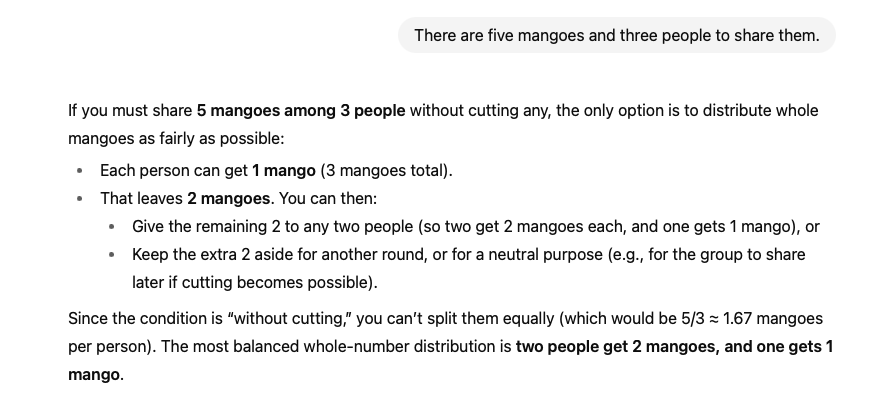

### Large Language Model (Highlevel) ###


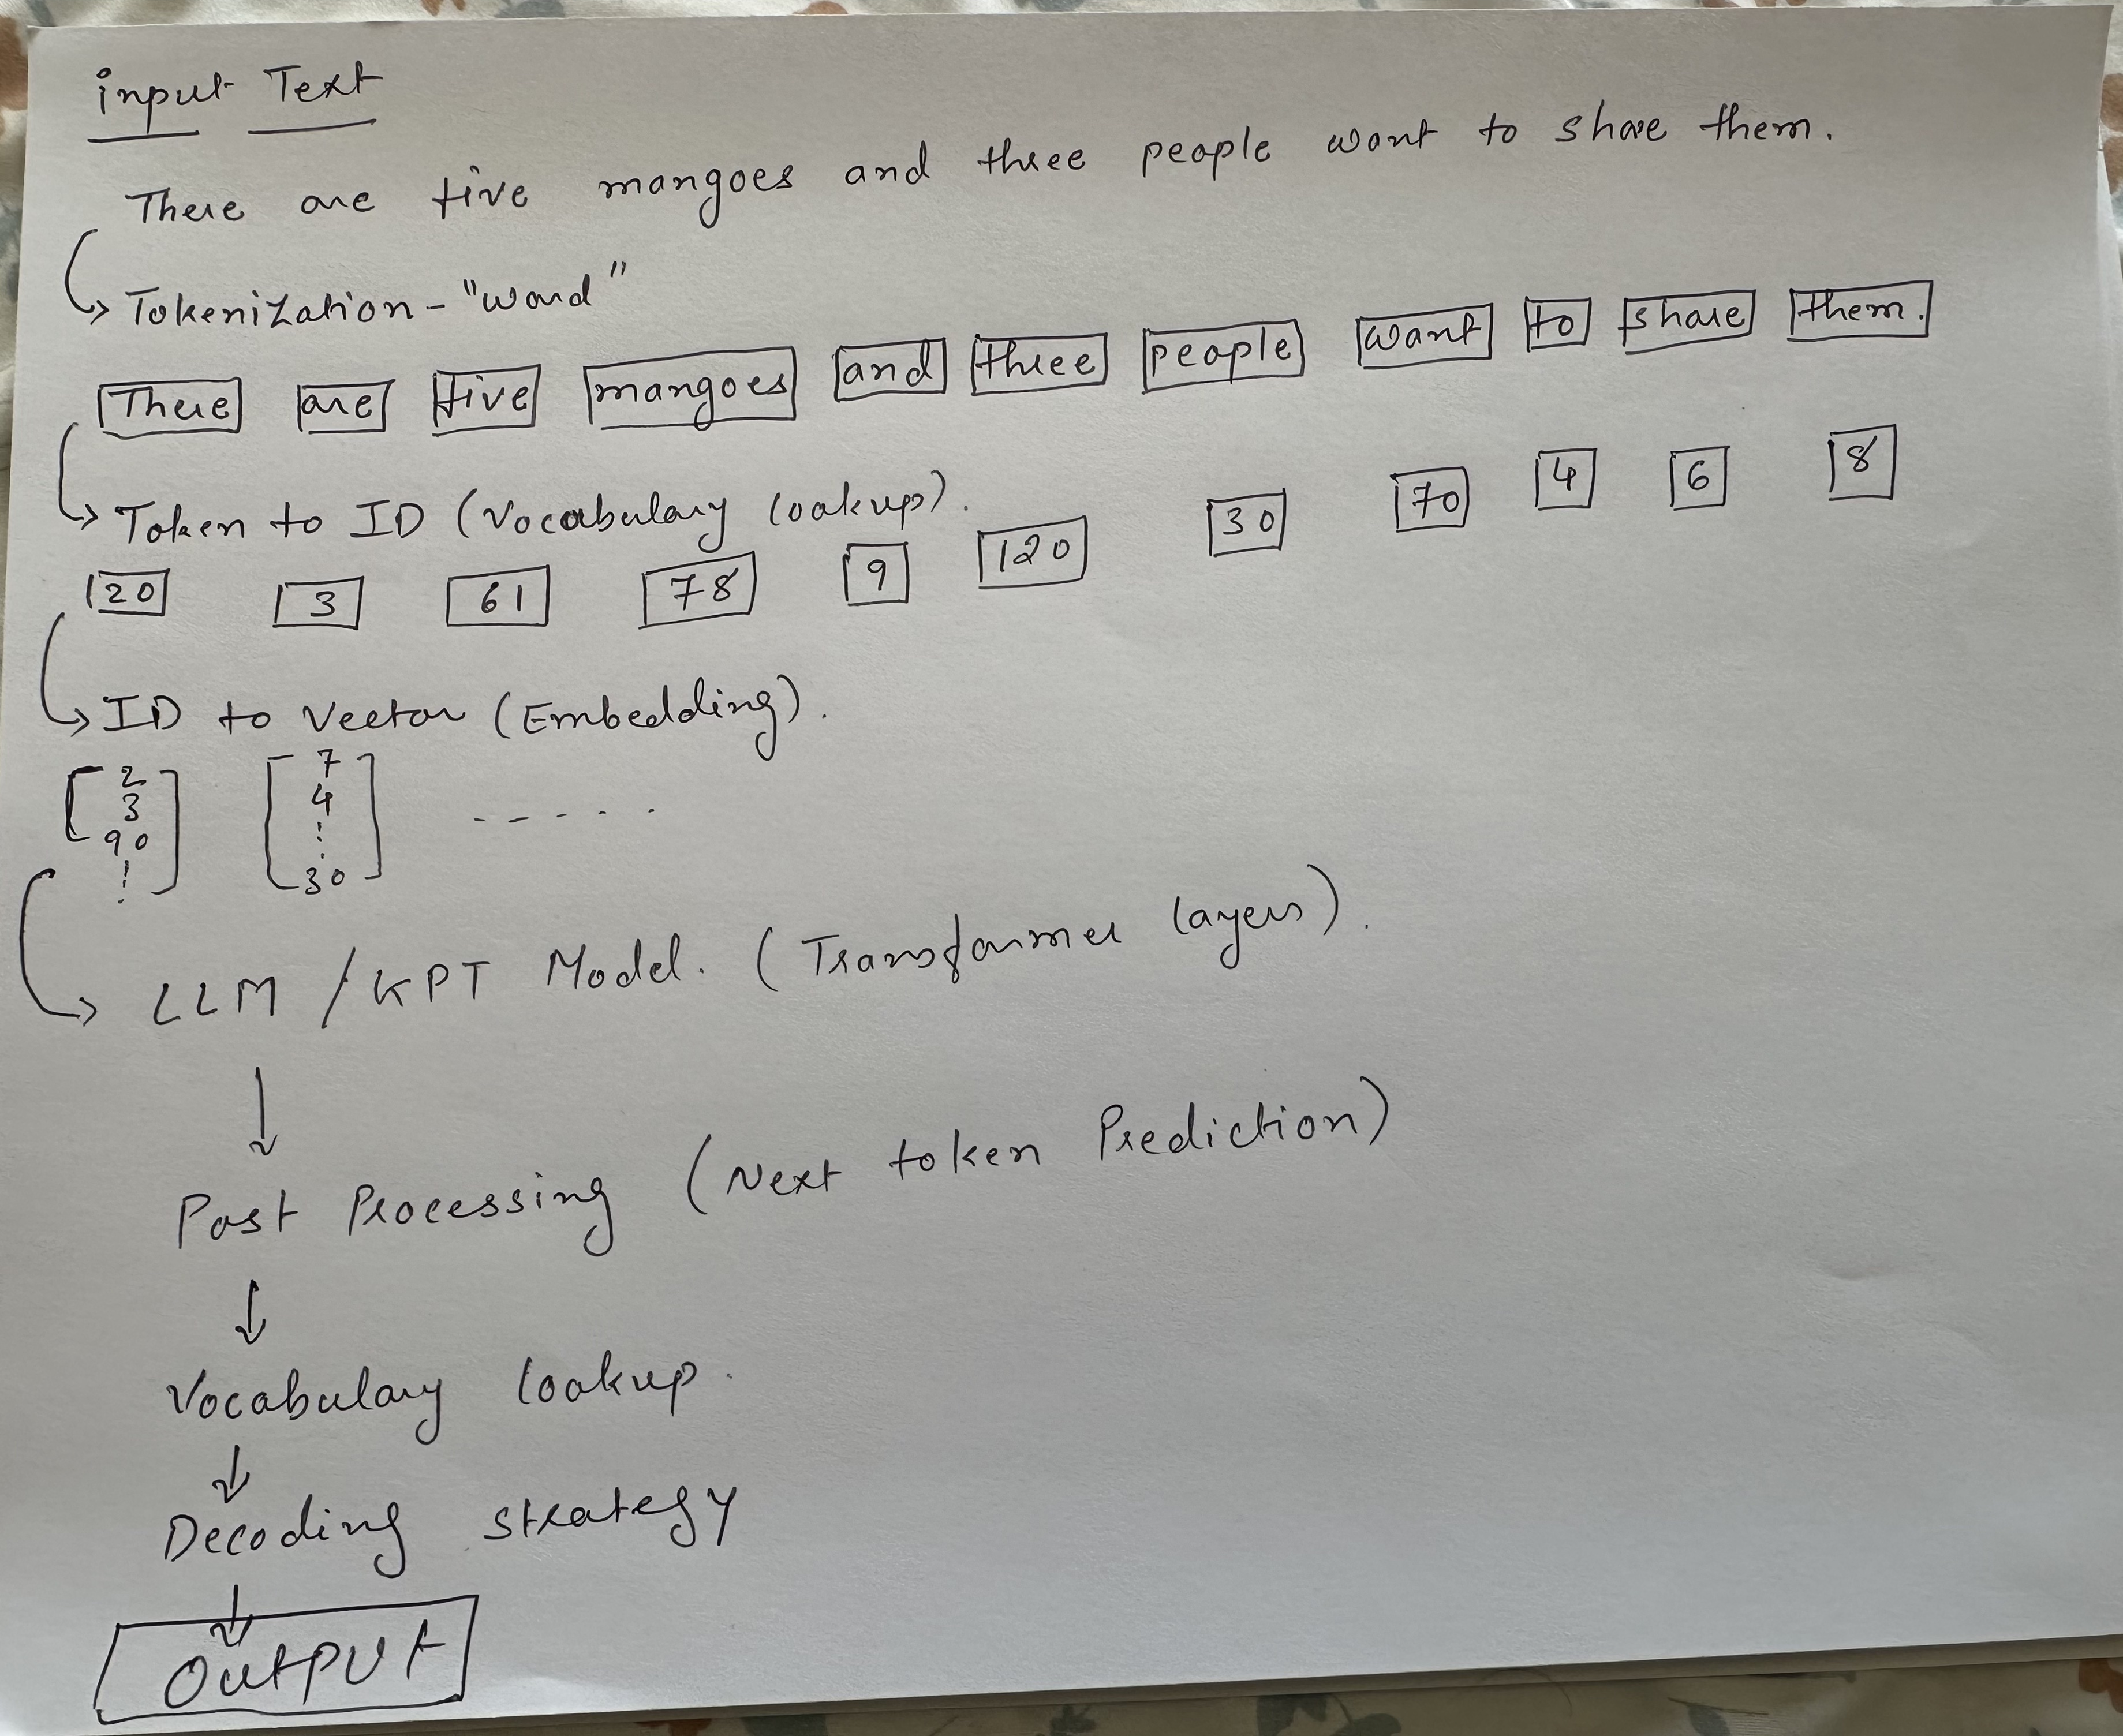

### Tokenization ###
 Tokenization is a process of splitting a stream of text into smaller units, called tokens, which can be words, subwords, or characters. These tokens are the basic building blocks that NLP systems operate on.

In early phase, NLP models relied heavily on **word-level tokenization** to build statistical counts and probabilities.

   **Bigram Language Model**  
    - Raw sentence: `"The cat sat on the mat"`  
    - After tokenization (word-level):  
        `[ "The", "cat", "sat", "on", "the", "mat" ]`  
    - Bigram counts:  
      - P("cat" | "The")  
      - P("sat" | "cat")  
      - P("on" | "sat")  
$$
P(\text{"cat"} \mid \text{"The"}) = \frac{\text{count("The cat")}}{\text{count("The")}}
$$

-  Numerator = how many times `"The cat"` appears in the corpus.  
  Denominator = how many times `"The"` appears in total.  
  These probabilities helped predict the next word or check sentence likelihood.

Unigram → probability of each word independently.

Bigram → probability of word given previous 1 word.

Trigram (3-gram) → probability of word given previous 2 words.

n-gram → probability of word given previous n−1 words.


### Tokenizer - Word based ###

- Algorithm
  - Build vocabulary
  - Get corpus
  - Tokenize

  - Get input text
  - Convert to token Id (Encode)
  - Revert to original input text (Decode)


#### Build vocabulary ####

- Download publicly available book - Autobiography of Benjamin Franklin

In [20]:
# Constants
FILENAME = 'book.txt'

In [21]:
import io
with io.open(FILENAME, 'r', encoding='utf-8', errors='ignore') as f:
    raw_lines = f.readlines()

In [22]:
print("Total raw lines read from file:", len(raw_lines))

Total raw lines read from file: 8558


In [23]:
text = "".join(raw_lines)
text = text.lstrip("\ufeff")
print("Total characters read from file:", len(text))

Total characters read from file: 458711


In [24]:
import random
print("\nRandom sample of lines:")
for line in random.sample(raw_lines, 5):
    print(line)


Random sample of lines:
opportunity of shortening it, which at length offered in a manner

My being many years in the Assembly, the majority of which were

signed, not the least objection being made.

may expect some Account of the Method we

_Just Published:_



#### Split data by white space (Word) ####

https://docs.python.org/3/library/re.html

In [25]:
import re
sample_text = "There are five mangoes, but only three people to share them. How should I do this?"
print(re.split(r'(\s)', sample_text))
## Difference between (\s) and \s+
print(re.split(r'\s+', sample_text))

['There', ' ', 'are', ' ', 'five', ' ', 'mangoes,', ' ', 'but', ' ', 'only', ' ', 'three', ' ', 'people', ' ', 'to', ' ', 'share', ' ', 'them.', ' ', 'How', ' ', 'should', ' ', 'I', ' ', 'do', ' ', 'this?']
['There', 'are', 'five', 'mangoes,', 'but', 'only', 'three', 'people', 'to', 'share', 'them.', 'How', 'should', 'I', 'do', 'this?']


In [26]:
print(re.split(r'[,.?]|\s+', sample_text))
# Difference between adjacent delimiters (Punctuations & whitespace)
print(re.split(r'[,.?\s]+', sample_text))

['There', 'are', 'five', 'mangoes', '', 'but', 'only', 'three', 'people', 'to', 'share', 'them', '', 'How', 'should', 'I', 'do', 'this', '']
['There', 'are', 'five', 'mangoes', 'but', 'only', 'three', 'people', 'to', 'share', 'them', 'How', 'should', 'I', 'do', 'this', '']


In [27]:
text_split = re.split(r'[,.?\s]+', sample_text)
sample_words = [item for item in text_split if item != '']
print(sample_words)

['There', 'are', 'five', 'mangoes', 'but', 'only', 'three', 'people', 'to', 'share', 'them', 'How', 'should', 'I', 'do', 'this']


##### use W+ to split by word ####


In [28]:
words = re.findall(r"\w+|[^\w\s]", text)

In [29]:
print("Total words:", len(words))

Total words: 97478


In [30]:
print("\nFirst 20 words:")
print(words[:20])


First 20 words:
['The', 'Project', 'Gutenberg', 'eBook', 'of', 'Autobiography', 'of', 'Benjamin', 'Franklin', 'This', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the']


#### Vocabulary with IDs ###

In [31]:
# Unique words
print(len(set(words)))

9625


In [32]:
vocab_words = sorted(set(words))

vocab_dict = {word: idx for idx, word in enumerate(vocab_words)}

print("Vocabulary size:", len(vocab_dict))

Vocabulary size: 9625


Last 20 words

In [33]:
# Print last 20 words and their ids
for word in vocab_words[-20:]:
    print(word, " - ", vocab_dict[word])

youths  -  9605
zeal  -  9606
zealots  -  9607
zealous  -  9608
zealously  -  9609
{  -  9610
|  -  9611
}  -  9612
£  -  9613
°  -  9614
´  -  9615
Ætat  -  9616
æconomist  -  9617
—  -  9618
‘  -  9619
’  -  9620
“  -  9621
”  -  9622
•  -  9623
™  -  9624


In [34]:
# Print 20 words and their ids
for word in vocab_words[500:520]:
    print(word, " - ", vocab_dict[word])

Battalions  -  500
Bay  -  501
Bayley  -  502
Be  -  503
Beatty  -  504
Beaux  -  505
Because  -  506
Bed  -  507
Beds  -  508
Bees  -  509
Before  -  510
Beggars  -  511
Beginning  -  512
Being  -  513
Belief  -  514
Benezet  -  515
Bengan  -  516
Benjamin  -  517
Berkshire  -  518
Berne  -  519


#### Text to Token, and Token to Text ####

In [66]:
# They are my friends.
# I like to go for a walk.
# What a beautiful day it is!
example_text = "What a beautiful day it is!"

example_words = re.findall(r"\w+|[^\w\s]", example_text)
print(example_words)

# Get Ids
example_tokens = [vocab_dict[w] for w in example_words]
print(example_tokens)

# From ids to original text
example_text_from_token = " ".join(next(word for word, idx in vocab_dict.items() if idx == token_id) for token_id in example_tokens)
example_text_from_token = re.sub(r"\s+([,.:;!?])", r"\1", example_text_from_token)
print(example_text_from_token)

['What', 'a', 'beautiful', 'day', 'it', 'is', '!']
[2482, 2949, 3512, 4398, 6248, 6243, 0]
What a beautiful day it is!


#### Class to Tokensize To-From Text ###

In [36]:
class SimpleWordTokenizer:
    def __init__(self, vocab_dict):
        self.vocab_dict = vocab_dict
        self.vocab_idx_dict = {idx: word for word, idx in vocab_dict.items()}

    def encode(self, text):
      words_from_text = re.findall(r"\w+|[^\w\s]", text)
      ids = [self.vocab_dict[w] for w in words_from_text]
      return ids

    def decode(self, ids):
      text_from_ids = " ".join([self.vocab_idx_dict[i] for i in ids])
      text_from_ids = re.sub(r"\s+([,.:;!?])", r"\1", text_from_ids)
      return text_from_ids

In [37]:
tokenizer_example = SimpleWordTokenizer(vocab_dict)

text = """I am very glad to see you all!"""
print(text)
ids = tokenizer_example.encode(text)
print(ids)
print("---------------------------------------------")
text_from_ids = tokenizer_example.decode(ids)
print(text_from_ids)

I am very glad to see you all!
[1261, 3202, 9305, 5624, 9024, 8247, 9596, 3172, 0]
---------------------------------------------
I am very glad to see you all!


##### Try with a word not in given vocabulary (Out-Of-Vocabulary OOV) ####

In [38]:
text = """My name is Kamal."""
print(text)
ids = tokenizer_example.encode(text)
print(ids)

My name is Kamal.


KeyError: 'Kamal'

#### Handling Out-Of-Vocabulary (OOV) tokens ####

- Add unk token to map to unknown token
- Add <endoftext> token to separate out multiple text corpus sources.


In [39]:
vocab_words_extended = sorted(set(words))
vocab_words_extended.extend(["<|endoftext|>", "<|unk|>"])
vocab_dict_extended = {word: idx for idx, word in enumerate(vocab_words_extended)}

# print last 10 words of vocab_dict_extended
for word in vocab_words_extended[-10:]:
    print(word, " - ", vocab_dict_extended[word])

æconomist  -  9617
—  -  9618
‘  -  9619
’  -  9620
“  -  9621
”  -  9622
•  -  9623
™  -  9624
<|endoftext|>  -  9625
<|unk|>  -  9626


In [41]:
class SimpleWordTokenizerExtended:
    def __init__(self, vocab_dict):
        self.vocab_dict = vocab_dict
        self.vocab_idx_dict = {idx: word for word, idx in vocab_dict.items()}

    def encode(self, text):
      words_from_text = re.findall(r"\w+|[^\w\s]", text)

      # replace Out-Of-Vocabulary token with <|unk|> token
      words_from_text = [word if word in self.vocab_dict else "<|unk|>" for word in words_from_text]
      ids = [self.vocab_dict[w] for w in words_from_text]
      return ids

    def decode(self, ids):
      text_from_ids = " ".join([self.vocab_idx_dict[i] for i in ids])
      text_from_ids = re.sub(r"\s+([,.:;!?])", r"\1", text_from_ids)
      return text_from_ids

In [42]:
tokenizer_extended_example = SimpleWordTokenizerExtended(vocab_dict_extended)

text = """My name is Kamal."""
print(text)
ids = tokenizer_extended_example.encode(text)
print(ids)

My name is Kamal.
[1627, 6821, 6243, 9626, 13]


In [43]:
print("---------------------------------------------")
text_from_ids = tokenizer_extended_example.decode(ids)
print(text_from_ids)

---------------------------------------------
My name is <|unk|>.


In [44]:
text = "I like to play golf."
print(text)
ids = tokenizer_extended_example.encode(text)
print(ids)
print("---------------------------------------------")
text_from_ids = tokenizer_extended_example.decode(ids)
print(text_from_ids)

I like to play golf.
[1261, 6457, 9024, 7316, 9626, 13]
---------------------------------------------
I like to play <|unk|>.


#### <font color="blue">Tokenizer - Character based</font> ####

In [45]:
import io
with io.open(FILENAME, 'r', encoding='utf-8', errors='ignore') as f:
    raw_lines = f.readlines()

print("Total raw lines read from file:", len(raw_lines))

text = "".join(raw_lines)
text = text.lstrip("\ufeff")
print("Total characters read from file:", len(text))


Total raw lines read from file: 8558
Total characters read from file: 458711


#### Vocabulary based on characters ####

In [46]:
chars = sorted(set(text))

print("Character vocab size:", len(chars))

Character vocab size: 105


##### Print vocabulary based on characters #####

In [47]:
print(chars)

['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '£', '°', '´', 'Æ', 'æ', 'è', 'é', 'ô', '—', '‘', '’', '“', '”', '•', '™']


In [48]:
char_vocab_dict = {c: idx for idx, c in enumerate(chars)}

print(char_vocab_dict)

{'\n': 0, ' ': 1, '!': 2, '"': 3, '#': 4, '$': 5, '%': 6, '&': 7, "'": 8, '(': 9, ')': 10, '*': 11, '+': 12, ',': 13, '-': 14, '.': 15, '/': 16, '0': 17, '1': 18, '2': 19, '3': 20, '4': 21, '5': 22, '6': 23, '7': 24, '8': 25, '9': 26, ':': 27, ';': 28, '=': 29, '?': 30, 'A': 31, 'B': 32, 'C': 33, 'D': 34, 'E': 35, 'F': 36, 'G': 37, 'H': 38, 'I': 39, 'J': 40, 'K': 41, 'L': 42, 'M': 43, 'N': 44, 'O': 45, 'P': 46, 'Q': 47, 'R': 48, 'S': 49, 'T': 50, 'U': 51, 'V': 52, 'W': 53, 'X': 54, 'Y': 55, 'Z': 56, '[': 57, ']': 58, '^': 59, '_': 60, 'a': 61, 'b': 62, 'c': 63, 'd': 64, 'e': 65, 'f': 66, 'g': 67, 'h': 68, 'i': 69, 'j': 70, 'k': 71, 'l': 72, 'm': 73, 'n': 74, 'o': 75, 'p': 76, 'q': 77, 'r': 78, 's': 79, 't': 80, 'u': 81, 'v': 82, 'w': 83, 'x': 84, 'y': 85, 'z': 86, '{': 87, '|': 88, '}': 89, '£': 90, '°': 91, '´': 92, 'Æ': 93, 'æ': 94, 'è': 95, 'é': 96, 'ô': 97, '—': 98, '‘': 99, '’': 100, '“': 101, '”': 102, '•': 103, '™': 104}


In [49]:
class SimpleCharTokenizer:
    def __init__(self, vocab_dict):
        self.vocab_dict = vocab_dict
        self.vocab_idx_dict = {idx: ch for ch, idx in vocab_dict.items()}

    def encode(self, text):
        # Just take characters as they are
        chars_from_text = list(text)
        ids = [self.vocab_dict[c] for c in chars_from_text if c in self.vocab_dict]
        return ids

    def decode(self, ids):
        # Reconstruct string directly (no spaces between chars)
        text_from_ids = "".join([self.vocab_idx_dict[i] for i in ids])
        return text_from_ids

In [50]:
charTokenizer = SimpleCharTokenizer(char_vocab_dict)

example = "I like data science."
ids = charTokenizer.encode(example)
print(ids)
print(charTokenizer.decode(ids))

[39, 1, 72, 69, 71, 65, 1, 64, 61, 80, 61, 1, 79, 63, 69, 65, 74, 63, 65, 15]
I like data science.


In [51]:
text = """My name is Kamal."""
print(text)
ids = charTokenizer.encode(text)
print(ids)
print(charTokenizer.decode(ids))

My name is Kamal.
[43, 85, 1, 74, 61, 73, 65, 1, 69, 79, 1, 41, 61, 73, 61, 72, 15]
My name is Kamal.


## Word-based vs Character-based Tokenizers: Pros & Cons

### Word-based Tokenizer
**Pros**
1. Tokens are meaningful units (easy to read and interpret).  
2. Shorter sequences (fewer tokens per sentence).  
3. Works well for common vocabulary in the training corpus.  

**Cons**
1. Out-of-Vocabulary (OOV) problem → fails on unseen/rare words.  
2. Vocabulary can grow very large (memory + storage overhead).  
3. Struggles with morphological variations (e.g., "run", "running", "runner").  

---

### Character-based Tokenizer
**Pros**
1. Very small vocabulary (typically 100–200 chars).  
2. No OOV problem → every string can be represented.  
3. Handles misspellings, new words, emojis, or special symbols naturally.  

**Cons**
1. Much longer sequences (one token per character).  
2. Harder for the model to capture meaning at the character level.  
3. Less efficient training/inference due to longer context windows.  


#### <font color="blue">Python libraries for word tokenization</font> #####

- **NLTK** and **spaCy** both provide word tokenization as an off-the-shelf feature.  

- **NLTK** — a classic Python library widely used for teaching and experimenting with NLP tasks such as tokenization, stemming, and tagging.  

- **spaCy** — a modern, production-ready NLP library optimized for speed, with built-in tools for tokenization, part-of-speech tagging, and named entity recognition.  


In [52]:
!pip install nltk

In [53]:
!pip install spacy

In [55]:
from nltk.tokenize import word_tokenize

sample_text = "My name is Kamal."
sample_word_tokens = word_tokenize(sample_text)
print(sample_word_tokens)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


##### Why do we need to download `punkt` and `punkt_tab`? ######

- **NLTK tokenizers** rely on pretrained data models (not just code).  
- `punkt` provides the statistical models for sentence and word tokenization.  
- `punkt_tab` includes supporting tables used by `punkt` to handle abbreviations and edge cases.  
- These resources are not bundled by default, so we download them once before using `nltk.word_tokenize()` or `nltk.sent_tokenize()`.  


In [56]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [57]:
from nltk.tokenize import word_tokenize

sample_text = "My name is Kamal."
sample_word_tokens = word_tokenize(sample_text)
print(sample_word_tokens)

['My', 'name', 'is', 'Kamal', '.']


#### Pretrained model for spaCy ####

- **spaCy models** (like `en_core_web_sm`) contain the language-specific data needed for tokenization and NLP tasks.  
- This small English model includes rules for word segmentation, part-of-speech tagging, and named entity recognition.  
- `spacy.load("en_core_web_sm")` loads the model into memory so that `nlp(text)` can process and tokenize text.  
- Without loading a model, spaCy cannot apply its linguistic pipeline to your input text.  


In [58]:
import spacy

nlp_spacy = spacy.load("en_core_web_sm")

sample_tex = "My name is Kamal."
sample_doc = nlp_spacy(sample_text)
sample_word_tokens = [token.text for token in sample_doc]
print(sample_word_tokens)

['My', 'name', 'is', 'Kamal', '.']


### Other Language - Tokenization ####

Chinese characters

In [59]:
!python -m spacy download zh_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 30.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [60]:
#spacy

text = "我喜欢自然语言处理。你呢？"
nlp = spacy.load("zh_core_web_sm")
doc = nlp(text)
print([t.text for t in doc])

['我', '喜欢', '自然', '语言', '处理', '。', '你', '呢', '？']


#### Hindi Characters ####

In [61]:
import nltk
from nltk.tokenize import word_tokenize

text = "मेरा नाम कमल है और मुझे किताबें पढ़ना बहुत पसंद है।"
print(word_tokenize(text))

['मेरा', 'नाम', 'कमल', 'है', 'और', 'मुझे', 'किताबें', 'पढ़ना', 'बहुत', 'पसंद', 'है।']


In [62]:
!python -m spacy download xx_ent_wiki_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 58.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [63]:
import spacy
nlp = spacy.load("xx_ent_wiki_sm")

text = "मेरा नाम कमल है और मुझे किताबें पढ़ना बहुत पसंद है।"
doc = nlp(text)
print([t.text for t in doc])

['मेरा', 'नाम', 'कमल', 'है', 'और', 'मुझे', 'किताबें', 'पढ़ना', 'बहुत', 'पसंद', 'है', '।']


#### <font color="blue">From Tokenization to Translation </font> ####

So far, we’ve learned how different languages are tokenized:
- English → space-based, works with NLTK/spaCy  
- Hindi → also space-based, works fine with NLTK/spaCy  
- Chinese → no spaces, needs special tools like Jieba or Chinese-specific models  


The next step in NLP is not just splitting text into tokens, but **understanding it across languages**.  
Let’s peek at how the same sentences could be translated into English using an off-the-shelf model.

In [64]:
!pip install transformers sentencepiece

In [65]:
from transformers import pipeline

translator_zh = pipeline("translation", model="Helsinki-NLP/opus-mt-zh-en")
translator_hi = pipeline("translation", model="Helsinki-NLP/opus-mt-hi-en")

chinese_text = "我喜欢自然语言处理。你呢？"
hindi_text = "मेरा नाम कमल है और मुझे किताबें पढ़ना बहुत पसंद है।"

print("Chinese:", chinese_text)
print("English:", translator_zh(chinese_text)[0]['translation_text'])

print("\nHindi:", hindi_text)
print("English:", translator_hi(hindi_text)[0]['translation_text'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

...

source.spm:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Chinese: 我喜欢自然语言处理。你呢？
English: I like natural languages. And you?

Hindi: मेरा नाम कमल है और मुझे किताबें पढ़ना बहुत पसंद है।
English: My name is Kol, and I love reading books.


#### Next section from me on (mostly on 9/27).... #####

So far, we’ve learned how to break text into tokens. But computers don’t actually understand words or characters — they only understand numbers. The next step is to see how tokens can be represented as numbers. We’ll start with Byte Pair Encoding (BPE) and then move into embeddings, which form the backbone of modern NLP models.